In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from __future__ import division, print_function, unicode_literals

# A. PHƯƠNG PHÁP K-NEAREST NEIGHBORS

## Ví dụ A1

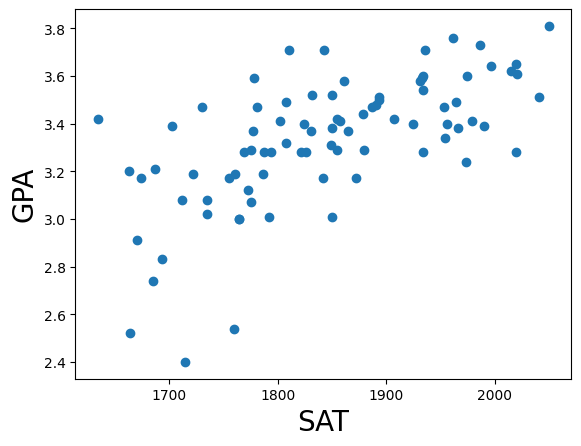

In [10]:
# Change to data path on your computer
data = \
pd.read_csv("D:/Workspace/HUS/Machine Learning/2. KNN-LR/SAT_GPA.csv")
# Show the description of data
data.describe()
# Set to training data (x, y)
y = data['GPA']
x = data['SAT']
# Remind that we need to put component x_0 = 1 to x
plt.scatter(x,y)
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

In [11]:
k = 8
def distance(array, value):
    array = np.array(array)
    return abs(array - value)
def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]
data_len = len(x)
X_train = np.array(x[:64])
Y_train = np.array(y[:64])
X_test = np.array(x[64:data_len])
Y_test = np.array(y[64:data_len])
k = 8

In [12]:
Y_pred = np.zeros(len(X_test))
for i in range(len(X_test)):
    indexis = find_nearest_index(X_train, X_test[i], k)
    for id in indexis:
        Y_pred[i] = Y_pred[i] + Y_train[id]
    Y_pred[i] = Y_pred[i]/len(indexis)
    print(Y_pred[i], ' | ', Y_test[i])

3.3925000000000005  |  3.51
3.2749999999999995  |  3.52
3.2949999999999995  |  3.52
3.3975000000000004  |  3.54
3.295  |  3.58
3.3974999999999995  |  3.58
3.3975000000000004  |  3.59
3.2587500000000005  |  3.59
3.3899999999999997  |  3.6
3.3975000000000004  |  3.6
3.3874999999999993  |  3.61
3.3874999999999993  |  3.62
3.3662499999999995  |  3.64
3.3874999999999993  |  3.65
3.2950000000000004  |  3.71
3.3975000000000004  |  3.71
3.30875  |  3.71
3.3662500000000004  |  3.73
3.37625  |  3.76
3.3874999999999993  |  3.81


In [13]:
#Hãy sử dụng các độ đo: MSE; MAE; R-square để đánh giá kết quả.
def MSE(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)
def MAE(y_true, y_pred):
    return np.mean(abs(y_true - y_pred))
def R_square(y_true, y_pred):
    y_mean = np.mean(y_true)
    SS_tot = np.sum((y_true - y_mean)**2)
    SS_res = np.sum((y_true - y_pred)**2)
    return 1 - (SS_res / SS_tot)

print("MSE: ", MSE(Y_test, Y_pred))
print("MAE: ", MAE(Y_test, Y_pred))
print("R-square: ", R_square(Y_test, Y_pred))

MSE:  0.08137789062500003
MAE:  0.2711875000000001
R-square:  -10.951518670142466


## Ví dụ A2.

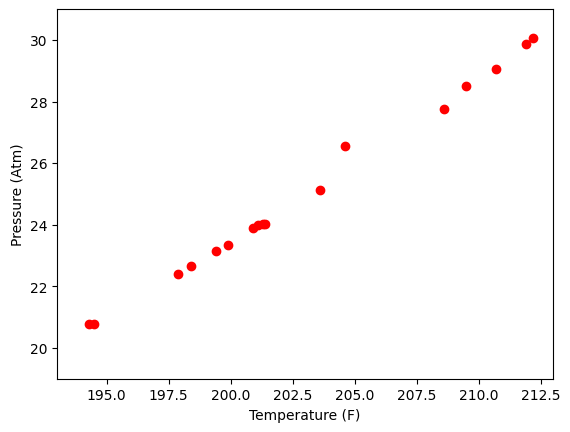

In [46]:
# Temp (F degree)
X = np.array([[194.5, 194.3, 197.9, 198.4, 199.4, 199.9, 200.9, 201.1, 201.4, 201.3, 203.6, 204.6, 209.5, 208.6, 210.7, 211.9, 212.2]]).T
# Press (Atm)
y = np.array([[20.79,20.79,22.4,22.67,23.15,23.35,23.89,23.99,24.02,24.01,25.14,26.57,28.49,27.76,29.04,29.88,30.06]]).T
# Visualize data
plt.plot(X, y, 'ro')
plt.axis([193, 213, 19, 31])
plt.xlabel('Temperature (F)')
plt.ylabel('Pressure (Atm)')
plt.show()

In [49]:
X_flat = X.flatten()
y_flat = y.flatten()

train_size = 16
k = 4

def distance(array, value):
    array = np.array(array)
    return abs(array - value)

def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]

data_len = len(X_flat)
X_train = X_flat[:train_size]
Y_train = y_flat[:train_size]
X_test = X_flat[train_size:data_len]
Y_test = y_flat[train_size:data_len]

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(Y_test)} samples")
print(f"Test values: {Y_test}")

Y_pred = np.zeros(len(X_test))
for i in range(len(X_test)):
    indexis = find_nearest_index(X_train, X_test[i], k)
    # Sửa lỗi: dùng np.mean thay vì loop để tính trung bình
    Y_pred[i] = np.mean(Y_train[indexis])
    print(f'Test {i+1}: X={X_test[i]:.1f}, Y_true={Y_test[i]:.2f}, Y_pred={Y_pred[i]:.2f}')

def MSE(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def MAE(y_true, y_pred):
    return np.mean(abs(y_true - y_pred))

def R_square(y_true, y_pred):
    y_mean = np.mean(y_true)
    SS_tot = np.sum((y_true - y_mean)**2)
    SS_res = np.sum((y_true - y_pred)**2)
    
    # Xử lý trường hợp SS_tot = 0 (khi test set có variance = 0)
    if SS_tot == 0:
        if SS_res == 0:
            return 1.0  # Perfect prediction
        else:
            print("Warning: SS_tot = 0 (no variance in test set), but model has prediction error")
            return float('-inf')
    
    r2 = 1 - (SS_res / SS_tot)
    return r2

mse = MSE(Y_test, Y_pred)
mae = MAE(Y_test, Y_pred)
r2 = R_square(Y_test, Y_pred)

print(f"\nKết quả đánh giá với k={k}:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-square: {r2:.4f}")

# Debug thông tin về R-square
y_mean = np.mean(Y_test)
SS_tot = np.sum((Y_test - y_mean)**2)
SS_res = np.sum((Y_test - Y_pred)**2)
print(f"\nDebug R-square:")
print(f"Test mean: {y_mean:.4f}")
print(f"SS_tot: {SS_tot:.4f}")
print(f"SS_res: {SS_res:.4f}")

# Giải thích kết quả R-square
if r2 == float('-inf'):
    print(f"R² = -∞ do test set không có variance (tất cả giá trị giống nhau)")
elif r2 < 0:
    print(f"R² âm nghĩa là mô hình dự đoán kém hơn việc dùng giá trị trung bình")
elif r2 >= 0:
    print(f"R² = {r2:.4f} - mô hình giải thích được {r2*100:.1f}% variance")

Training set: 16 samples
Test set: 1 samples
Test values: [30.06]
Test 1: X=212.2, Y_true=30.06, Y_pred=28.79

Kết quả đánh giá với k=4:
MSE: 1.6066
MAE: 1.2675
R-square: -inf

Debug R-square:
Test mean: 30.0600
SS_tot: 0.0000
SS_res: 1.6066
R² = -∞ do test set không có variance (tất cả giá trị giống nhau)


## Ví dụ A.3.

In [16]:
with open('D:/Workspace/HUS/Machine Learning/2. KNN-LR/fuel.txt') as f:
    lines = f.readlines()

x_data = []
y_data = []
lines.pop(0)  

for line in lines:
    splitted = line.replace('\n', '').split(',')
    splitted.pop(0)  
    splitted = list(map(float, splitted))
    fuel = 1000 * splitted[1] / splitted[5]  
    dlic = 1000 * splitted[0] / splitted[5]  
    logMiles = math.log2(splitted[3])        
    y_data.append(fuel)
    x_data.append([splitted[-1], dlic, splitted[2], logMiles])  

x_data = np.array(x_data)
y_data = np.array(y_data)

print(f"Data loaded: x_data shape {x_data.shape}, y_data shape {y_data.shape}")
print(f"First few x samples:\n{x_data[:3]}")
print(f"First few y samples: {y_data[:3]}")

Data loaded: x_data shape (51, 4), y_data shape (51,)
First few x samples:
[[1.80000000e+01 1.03138007e+03 2.34710000e+04 1.65271104e+01]
 [8.00000000e+00 1.03164106e+03 3.00640000e+04 1.37342862e+01]
 [1.80000000e+01 9.08597153e+02 2.55780000e+04 1.57535563e+01]]
First few y samples: [690.26441757 514.2792226  621.47507144]


In [17]:
x_flat = x_data.reshape(x_data.shape[0], -1)  
y_flat = y_data.flatten()

print(f"Data shape: x_data {x_flat.shape}, y_data {y_flat.shape}")

# Chia dữ liệu: 40 training, 11 validation
train_size = 40
k = 6

X_train = x_flat[:train_size]
Y_train = y_flat[:train_size]
X_test = x_flat[train_size:]
Y_test = y_flat[train_size:]

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(Y_test)} samples")

def distance_euclidean(array, value):
    array = np.array(array)
    return np.linalg.norm(array - value, ord=2, axis=1)

def find_nearest_index_euclidean(array, value, k):
    distances = distance_euclidean(array, value)
    return np.argsort(distances)[:k]

# Thực hiện prediction
Y_pred = np.zeros(len(X_test))
for i in range(len(X_test)):
    nearest_indices = find_nearest_index_euclidean(X_train, X_test[i], k)
    Y_pred[i] = np.mean(Y_train[nearest_indices])
    print(f'Test {i+1}: Y_true={Y_test[i]:.4f}, Y_pred={Y_pred[i]:.4f}')

def MSE_multi(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def MAE_multi(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def R_square_multi(y_true, y_pred):
    y_mean = np.mean(y_true)
    SS_tot = np.sum((y_true - y_mean)**2)
    SS_res = np.sum((y_true - y_pred)**2)
    
    if SS_tot == 0:
        if SS_res == 0:
            return 1.0
        else:
            print("Warning: SS_tot = 0")
            return float('-inf')
    
    r2 = 1 - (SS_res / SS_tot)
    return r2

mse = MSE_multi(Y_test, Y_pred)
mae = MAE_multi(Y_test, Y_pred)
r2 = R_square_multi(Y_test, Y_pred)

print(f"\n=== KẾT QUẢ ĐÁNH GIÁ VỚI K={k} (EUCLIDEAN DISTANCE) ===")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R-square: {r2:.6f}")

y_mean = np.mean(Y_test)
SS_tot = np.sum((Y_test - y_mean)**2)
SS_res = np.sum((Y_test - Y_pred)**2)

print(f"\nDebug R-square:")
print(f"Validation set mean: {y_mean:.6f}")
print(f"SS_tot: {SS_tot:.6f}")
print(f"SS_res: {SS_res:.6f}")

if r2 >= 0:
    print(f"R² = {r2:.6f} - mô hình giải thích được {r2*100:.2f}% variance")
else:
    print(f"R² âm ({r2:.6f}) - mô hình dự đoán kém hơn baseline")

Data shape: x_data (51, 4), y_data (51,)
Training set: 40 samples
Validation set: 11 samples
Test 1: Y_true=711.7331, Y_pred=655.9030
Test 2: Y_true=697.0528, Y_pred=638.4561
Test 3: Y_true=638.2311, Y_pred=638.4561
Test 4: Y_true=681.1001, Y_pred=611.9270
Test 5: Y_true=591.4999, Y_pred=655.9030
Test 6: Y_true=691.0227, Y_pred=644.4898
Test 7: Y_true=681.0311, Y_pred=588.0445
Test 8: Y_true=576.0697, Y_pred=605.0998
Test 9: Y_true=562.4109, Y_pred=662.6531
Test 10: Y_true=581.7937, Y_pred=584.9524
Test 11: Y_true=842.7918, Y_pred=644.4898

=== KẾT QUẢ ĐÁNH GIÁ VỚI K=6 (EUCLIDEAN DISTANCE) ===
MSE: 6956.363786
MAE: 65.316405
R-square: -0.139373

Debug R-square:
Validation set mean: 659.521542
SS_tot: 67159.736352
SS_res: 76520.001645
R² âm (-0.139373) - mô hình dự đoán kém hơn baseline


# B. PHƯƠNG PHÁP HỒI QUY TUYẾN TÍNH

## Bài tập B.1.

w =  [[-81.06372713]
 [  0.5228924 ]]


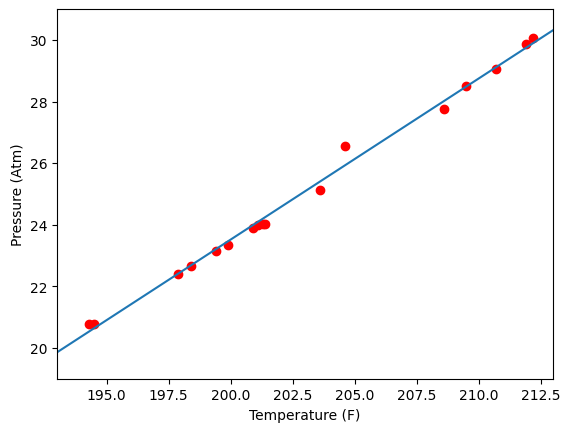

In [18]:
# Building Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

# Calculating weights of the fitting line
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)
# Preparing the fitting line
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(193, 213, 2)
y0 = w_0 + w_1*x0

# Drawing the fitting line
plt.plot(X.T, y.T, 'ro') # data
plt.plot(x0, y0) # the fitting line
plt.axis([193, 213, 19, 31])
plt.xlabel('Temperature (F)')
plt.ylabel('Pressure (Atm)')    
plt.show()

In [19]:
# Load training data here and assign to Xbar (obs. Data) and y (label)
# fit the model by Linear Regression
regr = linear_model.LinearRegression(fit_intercept=False)
# fit_intercept = False for calculating the bias
regr.fit(Xbar, y)


,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
train_size = 40
n_samples = x_flat.shape[0]
if train_size > n_samples:
    raise ValueError(f"train_size ({train_size}) is larger than available samples ({n_samples})")
# Build Xbar with intercept
one = np.ones((n_samples, 1))
Xbar = np.concatenate((one, x_flat), axis=1)
y = y_flat.reshape(-1)
# Split
Xbar_train = Xbar[:train_size, :]
y_train = y[:train_size]
Xbar_val = Xbar[train_size:, :]
y_val = y[train_size:]
print(f"Shapes -> Xbar: {Xbar.shape}, y: {y.shape}, train: {Xbar_train.shape}, val: {Xbar_val.shape}")
# Fit via normal equation
A = Xbar_train.T.dot(Xbar_train)
b = Xbar_train.T.dot(y_train.reshape(-1,1))
w = np.dot(np.linalg.pinv(A), b).reshape(-1)
print('Weights (normal eq):', w)
# Fit via sklearn for reference
regr2 = linear_model.LinearRegression(fit_intercept=False)
regr2.fit(Xbar_train, y_train)
print('Weights (sklearn):', regr2.coef_.reshape(-1))
# Predictions
y_train_pred = Xbar_train.dot(w)
y_val_pred = Xbar_val.dot(w)
# Metrics
def MSE(a,b):
    return np.mean((a-b)**2)
def MAE(a,b):
    return np.mean(np.abs(a-b))
def R_square(a,b):
    y_mean = np.mean(a)
    SS_tot = np.sum((a - y_mean)**2)
    SS_res = np.sum((a - b)**2)
    if SS_tot == 0:
        return 1.0 if SS_res == 0 else float('-inf')
    return 1 - (SS_res / SS_tot)
# Evaluate
mse_train = MSE(y_train, y_train_pred)
mae_train = MAE(y_train, y_train_pred)
r2_train = R_square(y_train, y_train_pred)
mse_val = MSE(y_val, y_val_pred)
mae_val = MAE(y_val, y_val_pred)
r2_val = R_square(y_val, y_val_pred)

print('\n=== Linear Regression trained on first 40 fuel samples ===')
print(f'Training samples: {len(y_train)}, Validation samples: {len(y_val)}')
print(f'MSE (train): {mse_train:.6f}')
print(f'MAE (train): {mae_train:.6f}')
print(f'R-square (train): {r2_train:.6f}')
print('')
print(f'MSE (val): {mse_val:.6f}')
print(f'MAE (val): {mae_val:.6f}')
print(f'R-square (val): {r2_val:.6f}')
print('')
# sklearn validation MSE
y_val_pred_sklearn = regr2.predict(Xbar_val)
print('Sklearn validation MSE:', MSE(y_val, y_val_pred_sklearn))


Shapes -> Xbar: (51, 5), y: (51,), train: (40, 5), val: (11, 5)
Weights (normal eq): [ 1.35142023e+02 -1.90301193e+00  4.18592399e-01 -6.22943009e-03
  1.95938559e+01]
Weights (sklearn): [ 1.35142023e+02 -1.90301193e+00  4.18592399e-01 -6.22943009e-03
  1.95938559e+01]

=== Linear Regression trained on first 40 fuel samples ===
Training samples: 40, Validation samples: 11
MSE (train): 3344.785764
MAE (train): 44.209736
R-square (train): 0.551560

MSE (val): 6253.362639
MAE (val): 60.615490
R-square (val): -0.024230

Sklearn validation MSE: 6253.362638613399


## Ví dụ B.3. (Bài tập thực hành 1)

### a. Sử dụng lại tệp dữ liệu cũng như đoạn lệnh đọc dữ liệu từ Ví dụ A.1.

Hệ số tương quan Pearson giữa SAT và GPA: 0.6372


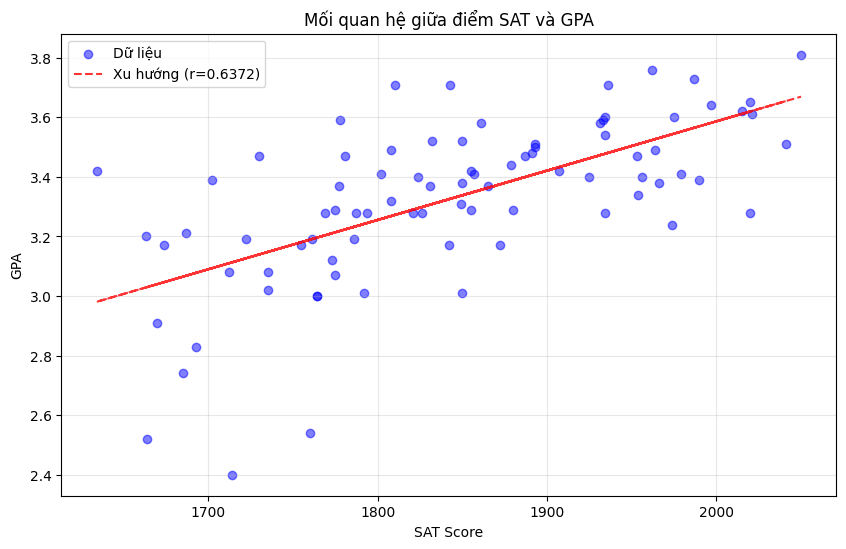

In [22]:
# 1. Tính hệ số tương quan Pearson
data = pd.read_csv("D:/Workspace/HUS/Machine Learning/2. KNN-LR/SAT_GPA.csv")
correlation = data['SAT'].corr(data['GPA'])
print(f"Hệ số tương quan Pearson giữa SAT và GPA: {correlation:.4f}")

# Vẽ scatter plot với đường thẳng xu hướng
plt.figure(figsize=(10, 6))
plt.scatter(data['SAT'], data['GPA'], color='blue', alpha=0.5, label='Dữ liệu')
z = np.polyfit(data['SAT'], data['GPA'], 1)
p = np.poly1d(z)
plt.plot(data['SAT'], p(data['SAT']), "r--", alpha=0.8, label=f'Xu hướng (r={correlation:.4f})')
plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.title('Mối quan hệ giữa điểm SAT và GPA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### b. Sử dụng lại tệp dữ liệu cũng như đoạn lệnh đọc dữ liệu từ Ví dụ A.1.

In [23]:
# 2. Chia dữ liệu thành tập training (64 mẫu) và validation
train_size = 64
X = data['SAT'].values.reshape(-1, 1)
y = data['GPA'].values

X_train = X[:train_size]
y_train = y[:train_size]
X_test = X[train_size:]
y_test = y[train_size:]

print(f"Kích thước tập training: {len(X_train)} mẫu")
print(f"Kích thước tập validation: {len(X_test)} mẫu")

Kích thước tập training: 64 mẫu
Kích thước tập validation: 20 mẫu


### c. Huấn luyện mô hình hồi quy tuyến tính và vẽ đồ thị

Hệ số hồi quy:
w0 (bias) = 0.8382
w1 (slope) = 0.0013

Phương trình hồi quy: GPA = 0.0013*SAT + 0.8382


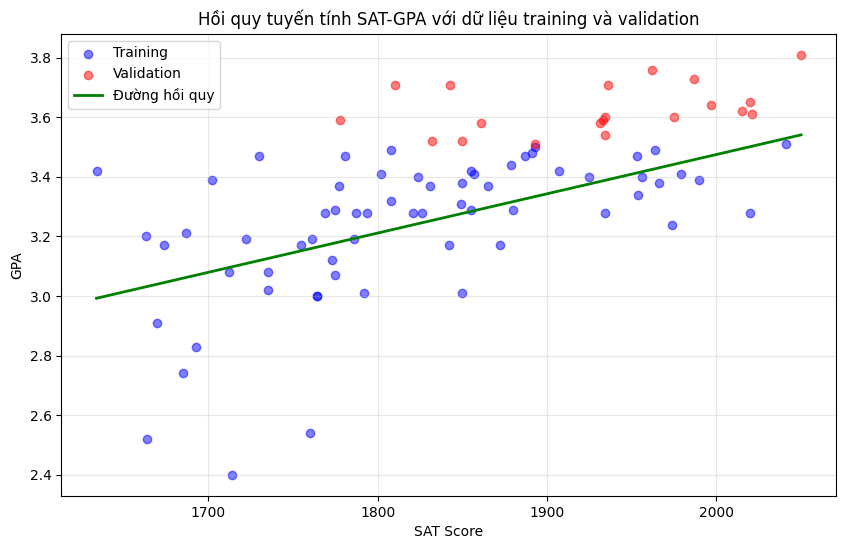

In [24]:
# Thêm cột bias (ones) vào X
X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
X_test_b = np.c_[np.ones((len(X_test), 1)), X_test]

# Tính hệ số hồi quy bằng normal equation
w = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train)
print('Hệ số hồi quy:')
print(f'w0 (bias) = {w[0]:.4f}')
print(f'w1 (slope) = {w[1]:.4f}')
print(f'\nPhương trình hồi quy: GPA = {w[1]:.4f}*SAT + {w[0]:.4f}')

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training')
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Validation')

# Vẽ đường hồi quy
X_new = np.array([[X[:, 0].min()], [X[:, 0].max()]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(w)
plt.plot(X_new, y_predict, "g-", linewidth=2, label='Đường hồi quy')

plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.title('Hồi quy tuyến tính SAT-GPA với dữ liệu training và validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### d. Đánh giá mô hình trên tập validation

In [25]:
y_train_pred = X_train_b.dot(w)
y_test_pred = X_test_b.dot(w)

def evaluate_metrics(y_true, y_pred, name=""):
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    print(f"\nKết quả đánh giá trên tập {name}:")
    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R-square: {r2:.6f}")
    return mse, mae, r2

# Đánh giá trên tập training
train_metrics = evaluate_metrics(y_train, y_train_pred, "training")

# Đánh giá trên tập validation
val_metrics = evaluate_metrics(y_test, y_test_pred, "validation")


Kết quả đánh giá trên tập training:
MSE: 0.040351
MAE: 0.146777
R-square: 0.291344

Kết quả đánh giá trên tập validation:
MSE: 0.072638
MAE: 0.248804
R-square: -9.667975


### e. So sánh với kết quả KNN từ ví dụ A.1


=== SO SÁNH KẾT QUẢ GIỮA LINEAR REGRESSION VÀ KNN ===

Linear Regression:

Kết quả đánh giá trên tập validation:
MSE: 0.072638
MAE: 0.248804
R-square: -9.667975

K-Nearest Neighbors (k=8):

Kết quả đánh giá trên tập validation:
MSE: 0.081378
MAE: 0.271188
R-square: -10.951519


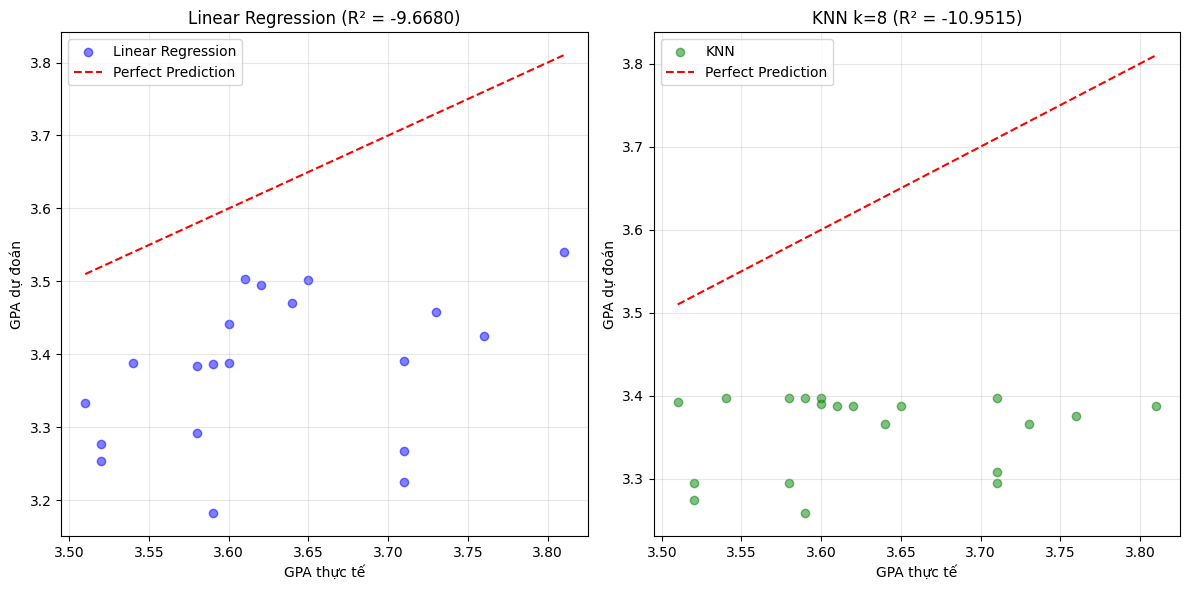


Kết luận so sánh:
- Linear Regression có R² = -9.6680
- KNN (k=8) có R² = -10.9515
→ Linear Regression cho kết quả tốt hơn trên tập validation


In [27]:
def knn_predict(X_train, y_train, X_test, k=8):
    y_pred = np.zeros(len(X_test))
    for i in range(len(X_test)):
        distances = np.abs(X_train - X_test[i])
        nearest = np.argsort(distances.flatten())[:k]
        y_pred[i] = np.mean(y_train[nearest])
    return y_pred

# Áp dụng KNN với k=8 (như trong ví dụ A.1)
k = 8
y_train_pred_knn = knn_predict(X_train, y_train, X_train, k)
y_test_pred_knn = knn_predict(X_train, y_train, X_test, k)

print("\n=== SO SÁNH KẾT QUẢ GIỮA LINEAR REGRESSION VÀ KNN ===")
print("\nLinear Regression:")
_, _, r2_lr = evaluate_metrics(y_test, y_test_pred, "validation")

print("\nK-Nearest Neighbors (k=8):")
_, _, r2_knn = evaluate_metrics(y_test, y_test_pred_knn, "validation")

# Vẽ đồ thị so sánh
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, c='blue', alpha=0.5, label='Linear Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('GPA thực tế')
plt.ylabel('GPA dự đoán')
plt.title(f'Linear Regression (R² = {r2_lr:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred_knn, c='green', alpha=0.5, label='KNN')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('GPA thực tế')
plt.ylabel('GPA dự đoán')
plt.title(f'KNN k=8 (R² = {r2_knn:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKết luận so sánh:")
print(f"- Linear Regression có R² = {r2_lr:.4f}")
print(f"- KNN (k=8) có R² = {r2_knn:.4f}")
if r2_lr > r2_knn:
    print("→ Linear Regression cho kết quả tốt hơn trên tập validation")
elif r2_lr < r2_knn:
    print("→ KNN cho kết quả tốt hơn trên tập validation")
else:
    print("→ Cả hai phương pháp cho kết quả tương đương")

## Ví dụ B.4 (Bài tập 2)

Kích thước dữ liệu:
Training set: X: (80, 5), y: (80,)
Testing set:  X: (20, 5), y: (20,)

Các hệ số hồi quy:
β₀ (bias)        = 0.0431
β₁ (tuổi)        = 0.0090
β₂ (cholesterol) = 0.0071
β₃ (glucose)     = 0.0081
β₄ (huyết áp)    = 0.0026
β₅ (BMI)         = -0.0005

Kết quả đánh giá trên tập test:
MSE: 0.227401
MAE: 0.305326
R-square: 0.214539


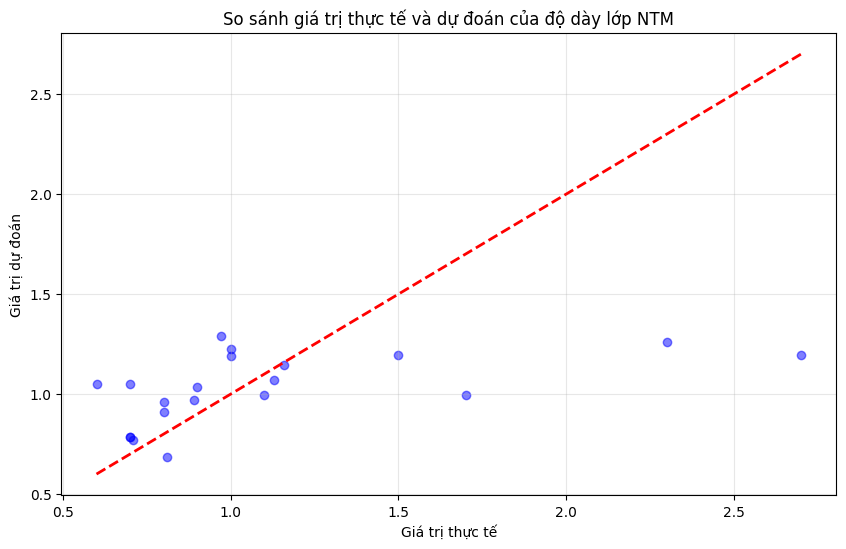


Phương trình hồi quy:
Độ dày NTM = 0.0431 + 0.0090*TUOI + 0.0071*CHOLESTEROL + 0.0081*GLUCOSE + 0.0026*HA + -0.0005*BMI


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Đọc dữ liệu từ file
data = pd.read_csv('D:/Workspace/HUS/Machine Learning/2. KNN-LR/vidu4_lin_reg.txt', delimiter=' ')

# Chuẩn bị dữ liệu đầu vào X và đầu ra y
X = data[['TUOI', 'CHOLESTEROL', 'GLUCOSE', 'HA', 'BMI']].values  # Các biến độc lập
y = data['BEDAYNTM'].values  # Biến phụ thuộc

# Chia dữ liệu thành tập training (80 mẫu) và testing (20 mẫu)
train_size = 80
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

print("Kích thước dữ liệu:")
print(f"Training set: X: {X_train.shape}, y: {y_train.shape}")
print(f"Testing set:  X: {X_test.shape}, y: {y_test.shape}")

# Thêm cột 1 vào đầu ma trận X cho hệ số β₀
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Tính các hệ số hồi quy bằng công thức normal equation
w = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train)

# In các hệ số hồi quy
print("\nCác hệ số hồi quy:")
print(f"β₀ (bias)        = {w[0]:.4f}")
print(f"β₁ (tuổi)        = {w[1]:.4f}")
print(f"β₂ (cholesterol) = {w[2]:.4f}")
print(f"β₃ (glucose)     = {w[3]:.4f}")
print(f"β₄ (huyết áp)    = {w[4]:.4f}")
print(f"β₅ (BMI)         = {w[5]:.4f}")

# Dự đoán trên tập test
y_pred = X_test_b.dot(w)

# Tính các độ đo đánh giá
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nKết quả đánh giá trên tập test:")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R-square: {r2:.6f}")

# Vẽ đồ thị so sánh giá trị thực tế và dự đoán
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('So sánh giá trị thực tế và dự đoán của độ dày lớp NTM')
plt.grid(True, alpha=0.3)
plt.show()

# In phương trình hồi quy
print("\nPhương trình hồi quy:")
print(f"Độ dày NTM = {w[0]:.4f} + {w[1]:.4f}*TUOI + {w[2]:.4f}*CHOLESTEROL + {w[3]:.4f}*GLUCOSE + {w[4]:.4f}*HA + {w[5]:.4f}*BMI")

## Ví dụ B.5. (Bài tập 3)

In [42]:
data = pd.read_csv('D:/Workspace/HUS/Machine Learning/2. KNN-LR/real_estate.csv')


In [43]:
# Biến độc lập X là các đặc trưng từ X1 đến X6
X = data[['X1 transaction date','X2 house age','X3 distance to the nearest MRT station','X4 number of convenience stores','X5 latitude','X6 longitude']].values
# Biến phụ thuộc y là giá nhà (Y)
y = data['Y house price of unit area'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Kích thước dữ liệu:")
print(f"Training set: X: {X_train.shape}, y: {y_train.shape}")
print(f"Testing set:  X: {X_test.shape}, y: {y_test.shape}")

X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Tính các hệ số hồi quy bằng công thức normal equation
w = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train)

# In các hệ số hồi quy
print("\nCác hệ số hồi quy:")
print(f"β₀ (bias)           = {w[0]:.4f}")
print(f"β₁ (khoảng cách MRT)= {w[1]:.4f}")
print(f"β₂ (số cửa hàng)    = {w[2]:.4f}")
print(f"β₃ (vĩ độ)          = {w[3]:.4f}")
print(f"β₄ (kinh độ)        = {w[4]:.4f}")
print(f"β₅ (tuổi nhà)       = {w[5]:.4f}")
print(f"β₆ (khoảng cách ga) = {w[6]:.4f}")

Kích thước dữ liệu:
Training set: X: (289, 6), y: (289,)
Testing set:  X: (125, 6), y: (125,)

Các hệ số hồi quy:
β₀ (bias)           = -11350.7399
β₁ (khoảng cách MRT)= 5.8478
β₂ (số cửa hàng)    = -0.2425
β₃ (vĩ độ)          = -0.0051
β₄ (kinh độ)        = 1.0745
β₅ (tuổi nhà)       = 239.0969
β₆ (khoảng cách ga) = -52.2352



Kết quả đánh giá trên tập test:
MSE: 73.568379
MAE: 6.184836
R-square: 0.560064


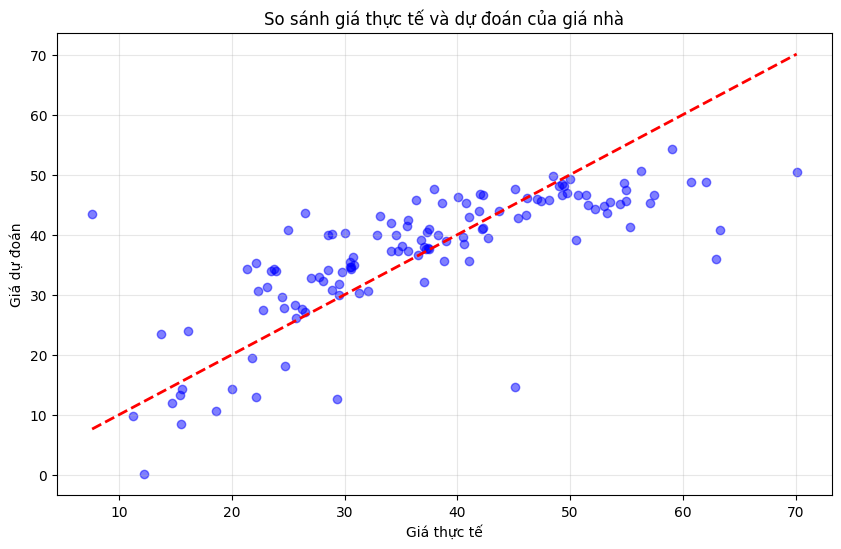


Phương trình hồi quy:
Giá nhà = -11350.7399 + 5.8478*X1 + -0.2425*X2 + -0.0051*X3 + 1.0745*X4 + 239.0969*X5 + -52.2352*X6

Hệ số tương quan với giá nhà:
Y house price of unit area                1.000000
X4 number of convenience stores           0.571005
X5 latitude                               0.546307
X6 longitude                              0.523287
X1 transaction date                       0.087491
No                                       -0.028587
X2 house age                             -0.210567
X3 distance to the nearest MRT station   -0.673613
Name: Y house price of unit area, dtype: float64


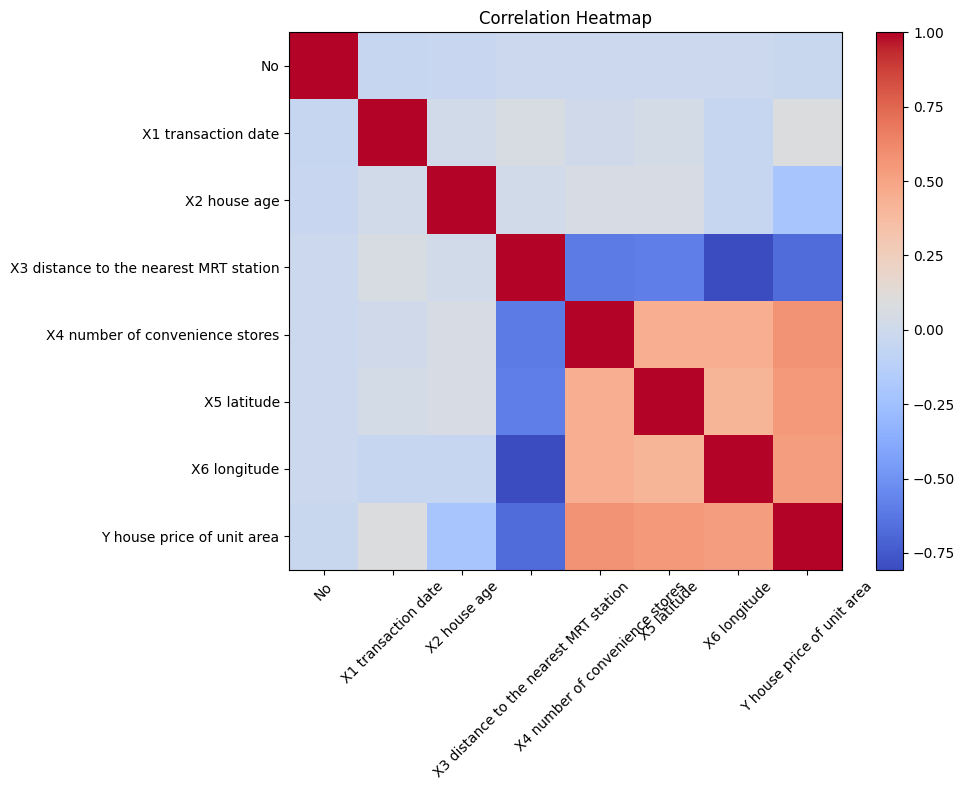

In [40]:
# Dự đoán trên tập test
y_pred = X_test_b.dot(w)

# Tính các độ đo đánh giá
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nKết quả đánh giá trên tập test:")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R-square: {r2:.6f}")

# Vẽ đồ thị so sánh giá trị thực tế và dự đoán
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('So sánh giá thực tế và dự đoán của giá nhà')
plt.grid(True, alpha=0.3)
plt.show()

# In phương trình hồi quy
print("\nPhương trình hồi quy:")
print("Giá nhà = {:.4f} + {:.4f}*X1 + {:.4f}*X2 + {:.4f}*X3 + {:.4f}*X4 + {:.4f}*X5 + {:.4f}*X6".format(*w))

# Phân tích mối quan hệ giữa các biến và giá nhà
correlations = data.corr()['Y house price of unit area'].sort_values(ascending=False)
print("\nHệ số tương quan với giá nhà:")
print(correlations)

# Vẽ biểu đồ correlation heatmap
plt.figure(figsize=(10, 8))
plt.imshow(data.corr(), cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(data.columns)), data.columns, rotation=45)
plt.yticks(range(len(data.columns)), data.columns)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


=== SO SÁNH KẾT QUẢ GIỮA LINEAR REGRESSION VÀ KNN (k=18) ===

Linear Regression:
MSE: 73.568379
MAE: 6.184836
R-square: 0.560064

K-Nearest Neighbors (k=18):
MSE: 63.263826
MAE: 5.754578
R-square: 0.621685


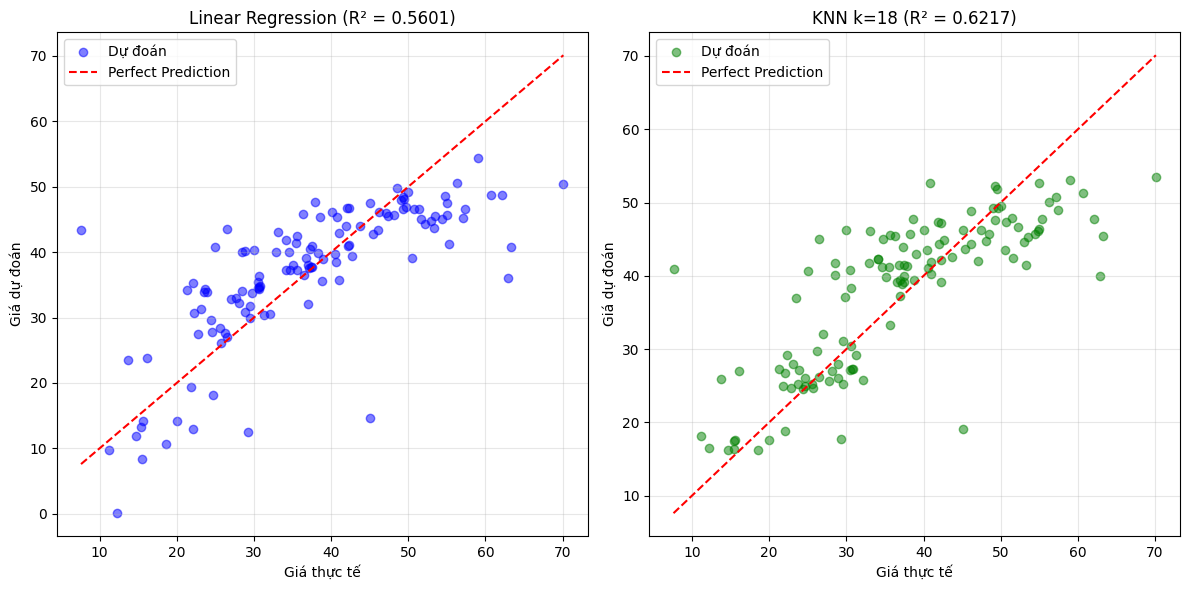


Kết luận so sánh:
- Linear Regression có R² = 0.5601
- KNN (k=18) có R² = 0.6217
→ KNN cho kết quả tốt hơn


In [44]:
# So sánh với KNN (k=18)
def knn_predict_for_real_estate(X_train, y_train, X_test, k):
    y_pred = np.zeros(len(X_test))
    for i in range(len(X_test)):
        # Tính khoảng cách Euclidean
        distances = np.sqrt(np.sum((X_train - X_test[i])**2, axis=1))
        # Lấy k điểm gần nhất
        nearest_indices = np.argsort(distances)[:k]
        # Dự đoán bằng trung bình của k láng giềng gần nhất
        y_pred[i] = np.mean(y_train[nearest_indices])
    return y_pred

# Áp dụng KNN với k=18
k = 18
print(f"\n=== SO SÁNH KẾT QUẢ GIỮA LINEAR REGRESSION VÀ KNN (k={k}) ===")

# Chuẩn hóa dữ liệu để KNN hoạt động tốt hơn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dự đoán với KNN
y_pred_knn = knn_predict_for_real_estate(X_train_scaled, y_train, X_test_scaled, k)

# Tính các độ đo đánh giá cho KNN
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("\nLinear Regression:")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R-square: {r2:.6f}")

print(f"\nK-Nearest Neighbors (k={k}):")
print(f"MSE: {mse_knn:.6f}")
print(f"MAE: {mae_knn:.6f}")
print(f"R-square: {r2_knn:.6f}")

# Vẽ đồ thị so sánh
plt.figure(figsize=(12, 6))

# Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, c='blue', alpha=0.5, label='Dự đoán')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title(f'Linear Regression (R² = {r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)

# KNN
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_knn, c='green', alpha=0.5, label='Dự đoán')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title(f'KNN k={k} (R² = {r2_knn:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKết luận so sánh:")
print(f"- Linear Regression có R² = {r2:.4f}")
print(f"- KNN (k={k}) có R² = {r2_knn:.4f}")
if r2 > r2_knn:
    print("→ Linear Regression cho kết quả tốt hơn")
elif r2 < r2_knn:
    print("→ KNN cho kết quả tốt hơn")
else:
    print("→ Cả hai phương pháp cho kết quả tương đương")